# Blue Catalyst Partial Analytics (Local Consolidated Notebook)

This notebook is the **local analytics/report notebook** for partial Blue Catalyst artifacts.
It is intentionally separate from the Apolo-deployed runbook.

It will:
1. Copy currently available artifacts/checkpoints into an interim snapshot folder.
2. Aggregate embeddings (from final NPZ or checkpoint batches).
3. Generate static/interactive figures + summary tables.
4. Write a machine-readable analytics summary.

In [1]:
from __future__ import annotations

import json
import os
import shutil
from dataclasses import dataclass
from datetime import datetime
from pathlib import Path
from typing import Any

import matplotlib

matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.manifold import TSNE
from sklearn.metrics import (
    average_precision_score,
    balanced_accuracy_score,
    roc_auc_score,
    silhouette_samples,
    silhouette_score,
)
from sklearn.metrics.pairwise import cosine_distances
from sklearn.model_selection import StratifiedKFold
from sklearn.neighbors import NearestNeighbors
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

try:
    import umap as umap_pkg

    HAS_UMAP = True
except ModuleNotFoundError:
    HAS_UMAP = False
    umap_pkg = None

try:
    import plotly.express as px

    HAS_PLOTLY = True
except ModuleNotFoundError:
    HAS_PLOTLY = False
    px = None


@dataclass
class LoadedEmbeddings:
    matrix: np.ndarray
    metadata: pd.DataFrame
    mode: str


def detect_latest_artifacts_dir(results_root: Path) -> Path:
    candidates = [p for p in (results_root / "runs").glob("*/artifacts") if p.is_dir()]
    if not candidates:
        raise FileNotFoundError(f"No artifact directories found under: {results_root / 'runs'}")
    return max(candidates, key=lambda p: p.stat().st_mtime)


def ensure_snapshot_dirs(output_root: Path, snapshot_name: str) -> dict[str, Path]:
    snapshot_dir = output_root / "interim_snapshots" / snapshot_name
    paths = {
        "snapshot": snapshot_dir,
        "fetched": snapshot_dir / "fetched_artifacts",
        "analytics": snapshot_dir / "analytics",
        "figures": snapshot_dir / "figures",
        "interactive": snapshot_dir / "interactive",
        "tables": snapshot_dir / "tables",
    }
    for p in paths.values():
        p.mkdir(parents=True, exist_ok=True)
    return paths


def copy_available_artifacts(source_dir: Path, target_dir: Path) -> list[str]:
    copied: list[str] = []
    files_to_copy = [
        "embedding_input_inventory.tsv",
        "embedding_coassembly_excluded.tsv",
        "sample_source_counts.tsv",
        "proteome_sample_manifest.tsv",
        "prjeb31266_selected_subset.tsv",
        "prjeb31266_analysis_manifest.tsv",
        "coassembly_excluded_from_primary.tsv",
        "prjeb31266_source_subset_seed.tsv",
        "embedding_metadata.tsv",
        "embedding_stats.json",
        "genome_embeddings.npz",
        "artifact_manifest.tsv",
        "artifact_manifest.json",
        "artifact_registry.tsv",
        "advanced_analytics_summary.json",
        "poc_metrics.json",
        "bridging_genomes_top.tsv",
        "embedding_projection_clusters.tsv",
    ]

    for name in files_to_copy:
        src = source_dir / name
        if src.exists() and src.is_file():
            shutil.copy2(src, target_dir / name)
            copied.append(name)

    src_checkpoints = source_dir / "embedding_checkpoints"
    if src_checkpoints.exists() and src_checkpoints.is_dir():
        dst_checkpoints = target_dir / "embedding_checkpoints"
        if dst_checkpoints.exists():
            shutil.rmtree(dst_checkpoints)
        shutil.copytree(src_checkpoints, dst_checkpoints)
        copied.append("embedding_checkpoints/")

    return copied


def load_from_final_npz(artifacts_dir: Path) -> LoadedEmbeddings | None:
    npz_path = artifacts_dir / "genome_embeddings.npz"
    if not npz_path.exists():
        return None

    bundle = np.load(npz_path, allow_pickle=True)
    meta = pd.DataFrame(
        {
            "sample": bundle["sample"].astype(str),
            "source": bundle["source"].astype(str),
            "ecosystem": bundle["ecosystem"].astype(str),
            "domain": bundle["domain"].astype(str),
            "n_proteins_used": bundle["n_proteins_used"].astype(int),
            "source_analysis_accession": (
                bundle["source_analysis_accession"].astype(str)
                if "source_analysis_accession" in bundle.files
                else ""
            ),
        }
    )
    return LoadedEmbeddings(
        matrix=bundle["embeddings"].astype(np.float32),
        metadata=meta,
        mode="final_npz",
    )


def aggregate_checkpoint_batches(artifacts_dir: Path) -> LoadedEmbeddings:
    ckpt_dir = artifacts_dir / "embedding_checkpoints"
    npz_files = sorted(ckpt_dir.glob("embedding_batch_*.npz"))
    if not npz_files:
        raise RuntimeError(f"No checkpoint npz files found in: {ckpt_dir}")

    mats: list[np.ndarray] = []
    metas: list[pd.DataFrame] = []
    for npz_path in npz_files:
        tsv_path = ckpt_dir / f"{npz_path.stem}.tsv"
        if not tsv_path.exists():
            raise RuntimeError(f"Missing checkpoint metadata TSV: {tsv_path}")
        block = np.load(npz_path, allow_pickle=True)["embeddings"].astype(np.float32)
        block_meta = pd.read_csv(tsv_path, sep="\t")
        if len(block_meta) != block.shape[0]:
            raise RuntimeError(
                f"Row mismatch for {npz_path.name}: embeddings={block.shape[0]} metadata={len(block_meta)}"
            )
        mats.append(block)
        metas.append(block_meta)

    meta = pd.concat(metas, ignore_index=True)
    if {"checkpoint_batch", "checkpoint_order"}.issubset(meta.columns):
        meta = meta.sort_values(["checkpoint_batch", "checkpoint_order"]).reset_index(drop=True)

    for col, default in {
        "sample": "",
        "source": "",
        "ecosystem": "",
        "domain": "",
        "source_analysis_accession": "",
        "n_proteins_used": 0,
    }.items():
        if col not in meta.columns:
            meta[col] = default
    meta["n_proteins_used"] = (
        pd.to_numeric(meta["n_proteins_used"], errors="coerce").fillna(0).astype(int)
    )

    if meta["sample"].astype(str).duplicated().any():
        raise RuntimeError("Duplicate sample IDs in checkpoint metadata")

    matrix = np.vstack(mats)
    if len(meta) != matrix.shape[0]:
        raise RuntimeError(
            f"Aggregated mismatch rows={len(meta)} embeddings={matrix.shape[0]}"
        )

    return LoadedEmbeddings(matrix=matrix, metadata=meta, mode="checkpoint_aggregate")


def attach_inventory_metadata(meta: pd.DataFrame, artifacts_dir: Path) -> pd.DataFrame:
    inventory = artifacts_dir / "embedding_input_inventory.tsv"
    if not inventory.exists():
        return meta
    inv = pd.read_csv(inventory, sep="\t")
    keep = [
        c
        for c in ["sample", "size_bytes", "exists", "already_checkpointed"]
        if c in inv.columns
    ]
    if "sample" not in keep:
        return meta
    merged = meta.merge(inv[keep].drop_duplicates(subset=["sample"]), on="sample", how="left")
    return merged.rename(columns={"size_bytes": "proteome_size_bytes"})


def safe_zscore(values: pd.Series | np.ndarray) -> np.ndarray:
    arr = np.asarray(values, dtype=float)
    sd = np.nanstd(arr)
    if (not np.isfinite(sd)) or sd == 0:
        return np.zeros_like(arr, dtype=float)
    return (arr - np.nanmean(arr)) / sd


def compute_permanova(
    labels: np.ndarray, d2: np.ndarray, permutations: int, seed: int
) -> dict[str, float]:
    rng = np.random.default_rng(seed)
    labels = np.asarray(labels)
    unique = np.unique(labels)
    n = len(labels)
    g = len(unique)
    if g < 2 or n <= g:
        return {
            "pseudo_f": float("nan"),
            "p_value": float("nan"),
            "r2": float("nan"),
            "permutations": permutations,
        }

    def ss_components(local: np.ndarray) -> tuple[float, float, float]:
        ss_total = float(d2.sum()) / (2.0 * n)
        ss_within = 0.0
        for val in np.unique(local):
            idx = np.flatnonzero(local == val)
            if len(idx) <= 1:
                continue
            ss_within += float(d2[np.ix_(idx, idx)].sum()) / (2.0 * len(idx))
        ss_between = ss_total - ss_within
        return ss_total, ss_between, ss_within

    obs_total, obs_between, obs_within = ss_components(labels)
    if obs_within <= 0:
        observed_f = float("inf")
    else:
        observed_f = (obs_between / max(1, g - 1)) / (obs_within / max(1, n - g))
    observed_r2 = obs_between / obs_total if obs_total > 0 else float("nan")

    ge = 0
    for _ in range(permutations):
        _, p_between, p_within = ss_components(rng.permutation(labels))
        if p_within <= 0:
            perm_f = float("inf")
        else:
            perm_f = (p_between / max(1, g - 1)) / (p_within / max(1, n - g))
        if perm_f >= observed_f:
            ge += 1

    return {
        "pseudo_f": float(observed_f),
        "p_value": (ge + 1) / (permutations + 1),
        "r2": float(observed_r2),
        "permutations": permutations,
    }


def bootstrap_silhouette(
    matrix: np.ndarray,
    labels: np.ndarray,
    seed: int,
    n_boot: int = 150,
) -> tuple[dict[str, float], np.ndarray]:
    labels = np.asarray(labels)
    classes = np.unique(labels)
    if len(classes) < 2:
        return (
            {
                "n_boot": 0,
                "mean": float("nan"),
                "ci95_low": float("nan"),
                "ci95_high": float("nan"),
            },
            np.array([], dtype=float),
        )

    rng = np.random.default_rng(seed)
    idx_by_class = {c: np.flatnonzero(labels == c) for c in classes}
    vals: list[float] = []
    for _ in range(n_boot):
        sample_idx = np.concatenate(
            [rng.choice(idxs, size=len(idxs), replace=True) for idxs in idx_by_class.values()]
        )
        bs_labels = labels[sample_idx]
        try:
            val = silhouette_score(matrix[sample_idx], bs_labels, metric="cosine")
            vals.append(float(val))
        except Exception:
            continue

    arr = np.array(vals, dtype=float)
    if len(arr) == 0:
        stats = {
            "n_boot": 0,
            "mean": float("nan"),
            "ci95_low": float("nan"),
            "ci95_high": float("nan"),
        }
    else:
        stats = {
            "n_boot": int(len(arr)),
            "mean": float(np.mean(arr)),
            "ci95_low": float(np.percentile(arr, 2.5)),
            "ci95_high": float(np.percentile(arr, 97.5)),
        }
    return stats, arr


def cross_validated_ecosystem_classifier(
    matrix: np.ndarray,
    labels: np.ndarray,
    seed: int,
) -> dict[str, Any]:
    labels = np.asarray(labels).astype(str)
    classes = np.unique(labels)
    if len(classes) != 2:
        return {
            "positive_class": None,
            "auc": float("nan"),
            "auprc": float("nan"),
            "balanced_accuracy": float("nan"),
            "fold_metrics": [],
        }

    positive = "wetland" if "wetland" in classes else classes[1]
    y = (labels == positive).astype(int)
    class_counts = np.bincount(y)
    if np.min(class_counts) < 3:
        return {
            "positive_class": positive,
            "auc": float("nan"),
            "auprc": float("nan"),
            "balanced_accuracy": float("nan"),
            "fold_metrics": [],
        }

    n_splits = min(5, int(np.min(class_counts)))
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)

    prob = np.zeros(len(y), dtype=float)
    pred = np.zeros(len(y), dtype=int)
    fold_metrics: list[dict[str, float]] = []

    for fold_idx, (tr, te) in enumerate(cv.split(matrix, y), start=1):
        n_comp = min(50, matrix.shape[1], len(tr) - 1)
        model = Pipeline(
            steps=[
                ("scale", StandardScaler()),
                ("pca", PCA(n_components=n_comp, random_state=seed)),
                (
                    "clf",
                    LogisticRegression(
                        max_iter=3000,
                        class_weight="balanced",
                        random_state=seed,
                    ),
                ),
            ]
        )
        model.fit(matrix[tr], y[tr])
        p = model.predict_proba(matrix[te])[:, 1]
        yhat = (p >= 0.5).astype(int)

        prob[te] = p
        pred[te] = yhat
        fold_metrics.append(
            {
                "fold": int(fold_idx),
                "auc": float(roc_auc_score(y[te], p)),
                "auprc": float(average_precision_score(y[te], p)),
                "balanced_accuracy": float(balanced_accuracy_score(y[te], yhat)),
            }
        )

    return {
        "positive_class": positive,
        "auc": float(roc_auc_score(y, prob)),
        "auprc": float(average_precision_score(y, prob)),
        "balanced_accuracy": float(balanced_accuracy_score(y, pred)),
        "fold_metrics": fold_metrics,
    }


def run_analytics(
    loaded: LoadedEmbeddings,
    out_figures: Path,
    out_interactive: Path,
    out_tables: Path,
    max_heatmap_samples: int,
    knn_k: int,
    permutations: int,
    seed: int,
) -> tuple[dict[str, Any], pd.DataFrame]:
    meta = loaded.metadata.copy().reset_index(drop=True)
    matrix = loaded.matrix

    keep = np.isfinite(matrix).all(axis=1)
    matrix = matrix[keep]
    meta = meta.loc[keep].reset_index(drop=True)

    n = len(meta)
    if n < 5:
        raise RuntimeError(f"Need at least 5 embeddings for analytics; got {n}")

    pca = PCA(n_components=min(20, n, matrix.shape[1]), random_state=seed)
    pcs = pca.fit_transform(matrix)

    if HAS_UMAP and n >= 15:
        reducer = umap_pkg.UMAP(
            n_neighbors=min(20, n - 1),
            min_dist=0.15,
            metric="cosine",
            random_state=seed,
        )
        U = reducer.fit_transform(matrix)
        umap_mode = "umap"
    else:
        U = pcs[:, :2]
        umap_mode = "pca_fallback"

    perplexity = min(30, max(5, (n - 1) // 3))
    T = TSNE(n_components=2, perplexity=perplexity, random_state=seed, init="pca").fit_transform(matrix)

    proj = meta.copy()
    proj["pc1"], proj["pc2"] = pcs[:, 0], pcs[:, 1]
    proj["umap1"], proj["umap2"] = U[:, 0], U[:, 1]
    proj["tsne1"], proj["tsne2"] = T[:, 0], T[:, 1]

    ecosystems = proj["ecosystem"].astype(str).values
    nn = NearestNeighbors(n_neighbors=min(knn_k + 1, n), metric="cosine").fit(matrix)
    nn_dist, nn_idx = nn.kneighbors(matrix, return_distance=True)
    neighbor_idx = nn_idx[:, 1:]
    neighbor_dist = nn_dist[:, 1:]
    k_eff = max(1, neighbor_idx.shape[1])

    opp_frac = []
    for i in range(n):
        neigh_labels = ecosystems[neighbor_idx[i]]
        opp_frac.append(float(np.mean(neigh_labels != ecosystems[i])) if len(neigh_labels) else 0.0)
    proj["opp_neighbor_fraction"] = np.array(opp_frac, dtype=float)
    proj["same_neighbor_fraction"] = 1.0 - proj["opp_neighbor_fraction"]

    p = np.clip(proj["opp_neighbor_fraction"].to_numpy(), 1e-8, 1 - 1e-8)
    proj["bridge_entropy"] = -(p * np.log2(p) + (1 - p) * np.log2(1 - p))

    eco_counts = pd.Series(ecosystems).value_counts()
    expected_opp = np.array(
        [1.0 - ((eco_counts[e] - 1) / max(1, n - 1)) for e in ecosystems], dtype=float
    )
    proj["expected_opp_fraction"] = expected_opp
    proj["mixing_excess"] = proj["opp_neighbor_fraction"] - proj["expected_opp_fraction"]
    binom_var = np.maximum(expected_opp * (1.0 - expected_opp) / k_eff, 1e-9)
    proj["mixing_zscore"] = proj["mixing_excess"] / np.sqrt(binom_var)

    proj["local_mean_cosine_distance"] = np.mean(neighbor_dist, axis=1)

    d = cosine_distances(matrix)
    nearest_same = np.full(n, np.nan, dtype=float)
    nearest_opp = np.full(n, np.nan, dtype=float)
    for i in range(n):
        same_mask = ecosystems == ecosystems[i]
        same_mask[i] = False
        opp_mask = ecosystems != ecosystems[i]
        if np.any(same_mask):
            nearest_same[i] = float(np.min(d[i, same_mask]))
        if np.any(opp_mask):
            nearest_opp[i] = float(np.min(d[i, opp_mask]))

    proj["nearest_same_distance"] = nearest_same
    proj["nearest_opposite_distance"] = nearest_opp
    proj["opposite_affinity_margin"] = proj["nearest_opposite_distance"] - proj["nearest_same_distance"]
    proj["boundary_balance_score"] = -np.abs(proj["opposite_affinity_margin"])

    proj["alpha_transfer_score"] = (
        safe_zscore(proj["bridge_entropy"])
        + safe_zscore(proj["boundary_balance_score"])
        + safe_zscore(-proj["local_mean_cosine_distance"])
    ) / 3.0

    bridge_top = proj.sort_values("bridge_entropy", ascending=False).head(30)
    bridge_top.to_csv(out_tables / "bridge_genomes_top30_partial.tsv", sep="\t", index=False)

    bridge_top_per_ecosystem = (
        proj.sort_values("bridge_entropy", ascending=False)
        .groupby("ecosystem", as_index=False, group_keys=False)
        .head(12)
    )
    bridge_top_per_ecosystem.to_csv(
        out_tables / "bridge_genomes_top12_per_ecosystem.tsv", sep="\t", index=False
    )

    alpha_top = proj.sort_values("alpha_transfer_score", ascending=False).head(40)
    alpha_top.to_csv(out_tables / "alpha_transfer_candidates_top40.tsv", sep="\t", index=False)

    alpha_top_per_ecosystem = (
        proj.sort_values("alpha_transfer_score", ascending=False)
        .groupby("ecosystem", as_index=False, group_keys=False)
        .head(20)
    )
    alpha_top_per_ecosystem.to_csv(
        out_tables / "alpha_transfer_top20_per_ecosystem.tsv", sep="\t", index=False
    )

    counts = proj["ecosystem"].value_counts()
    if len(counts) >= 2 and (counts >= 2).all():
        proj["silhouette"] = silhouette_samples(matrix, proj["ecosystem"].values, metric="cosine")
        sil_global = float(silhouette_score(matrix, proj["ecosystem"].values, metric="cosine"))
    else:
        proj["silhouette"] = np.nan
        sil_global = float("nan")

    perm = compute_permanova(proj["ecosystem"].astype(str).values, d * d, permutations, seed)
    sil_boot_stats, sil_boot_samples = bootstrap_silhouette(
        matrix,
        proj["ecosystem"].astype(str).values,
        seed=seed,
        n_boot=150,
    )
    cls_metrics = cross_validated_ecosystem_classifier(
        matrix,
        proj["ecosystem"].astype(str).values,
        seed=seed,
    )

    if {"rumen", "wetland"}.issubset(set(proj["ecosystem"].unique())):
        v = matrix[proj["ecosystem"] == "wetland"].mean(axis=0) - matrix[proj["ecosystem"] == "rumen"].mean(axis=0)
        norm = np.linalg.norm(v)
        proj["ecosystem_axis_projection"] = matrix @ (v / norm) if norm > 0 else 0.0
    else:
        proj["ecosystem_axis_projection"] = 0.0

    source_ct = pd.crosstab(proj["ecosystem"], proj["source"])
    source_purity = (
        source_ct.div(source_ct.sum(axis=1), axis=0).max(axis=1).fillna(0.0).to_dict()
    )
    source_confounded = bool(all(v >= 0.95 for v in source_purity.values()))

    domain_ct = pd.crosstab(proj["ecosystem"], proj["domain"])
    domain_unknown_fraction = {}
    if "Unknown" in domain_ct.columns:
        domain_unknown_fraction = (
            domain_ct.div(domain_ct.sum(axis=1), axis=0)["Unknown"].fillna(0.0).to_dict()
        )

    scientific_caveats: list[str] = []
    if source_confounded:
        scientific_caveats.append(
            "ecosystem and source are near-perfectly confounded; separation signal may reflect cohort source effects in addition to biology"
        )
    if domain_unknown_fraction and any(v > 0.5 for v in domain_unknown_fraction.values()):
        scientific_caveats.append(
            "at least one ecosystem has >50% Unknown domain labels; taxonomic interpretation should be treated as provisional"
        )

    sns.set_theme(style="whitegrid", context="talk")
    palette = {"rumen": "#9b2226", "wetland": "#0a9396"}

    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    sns.scatterplot(
        data=proj,
        x="pc1",
        y="pc2",
        hue="ecosystem",
        style="source",
        palette=palette,
        s=42,
        alpha=0.82,
        linewidth=0,
        ax=axes[0, 0],
    )
    axes[0, 0].set_title("PCA landscape")

    sns.scatterplot(
        data=proj,
        x="umap1",
        y="umap2",
        hue="ecosystem",
        style="source",
        palette=palette,
        s=42,
        alpha=0.82,
        linewidth=0,
        ax=axes[0, 1],
    )
    axes[0, 1].set_title(f"UMAP landscape ({umap_mode})")

    sns.scatterplot(
        data=proj,
        x="tsne1",
        y="tsne2",
        hue="ecosystem",
        style="source",
        palette=palette,
        s=42,
        alpha=0.82,
        linewidth=0,
        ax=axes[1, 0],
    )
    axes[1, 0].set_title("t-SNE landscape")

    sns.histplot(
        data=proj,
        x="bridge_entropy",
        hue="ecosystem",
        bins=22,
        kde=True,
        element="step",
        stat="density",
        common_norm=False,
        ax=axes[1, 1],
    )
    axes[1, 1].set_title("Neighborhood entropy distribution")
    axes[1, 1].set_xlim(0, 1)
    fig.tight_layout()
    fig.savefig(out_figures / "projection_landscapes_panel.png", dpi=220)
    plt.close(fig)

    fig, ax = plt.subplots(figsize=(10, 6))
    var = pca.explained_variance_ratio_ * 100.0
    ax.plot(np.arange(1, len(var) + 1), var, marker="o", color="#005f73")
    ax.set_xlabel("Principal component")
    ax.set_ylabel("Explained variance (%)")
    ax.set_title("PCA variance spectrum")
    fig.tight_layout()
    fig.savefig(out_figures / "pca_scree.png", dpi=220)
    plt.close(fig)

    rng = np.random.default_rng(seed)
    idx = (
        np.sort(rng.choice(n, size=max_heatmap_samples, replace=False))
        if n > max_heatmap_samples
        else np.arange(n)
    )
    hm = d[np.ix_(idx, idx)]
    eco_counts_hm = pd.Series(proj.iloc[idx]["ecosystem"]).value_counts().to_dict()
    fig, ax = plt.subplots(figsize=(12, 10))
    sns.heatmap(hm, cmap="mako", ax=ax, cbar_kws={"label": "cosine distance"})
    ax.set_title("Pairwise cosine distance heatmap (sampled)")
    ax.set_xlabel(f"Genomes (n={len(idx)}; ecosystems={eco_counts_hm})")
    ax.set_ylabel("Genomes")
    fig.tight_layout()
    fig.savefig(out_figures / "cosine_distance_heatmap_sampled.png", dpi=220)
    plt.close(fig)

    if proj["silhouette"].notna().any():
        fig, ax = plt.subplots(figsize=(10, 6))
        sns.violinplot(
            data=proj,
            x="ecosystem",
            y="silhouette",
            hue="ecosystem",
            palette="Set2",
            legend=False,
            ax=ax,
        )
        sns.stripplot(
            data=proj.sample(min(len(proj), 250), random_state=seed),
            x="ecosystem",
            y="silhouette",
            color="black",
            size=2,
            alpha=0.35,
            ax=ax,
        )
        ax.set_title("Per-genome silhouette by ecosystem")
        fig.tight_layout()
        fig.savefig(out_figures / "silhouette_by_ecosystem.png", dpi=220)
        plt.close(fig)

    fig, ax = plt.subplots(figsize=(10, 6))
    sns.kdeplot(
        data=proj,
        x="ecosystem_axis_projection",
        hue="ecosystem",
        fill=True,
        common_norm=False,
        alpha=0.35,
        ax=ax,
    )
    ax.set_title("Projection on rumen -> wetland trajectory axis")
    fig.tight_layout()
    fig.savefig(out_figures / "ecosystem_trajectory_axis.png", dpi=220)
    plt.close(fig)

    fig, axes = plt.subplots(2, 2, figsize=(16, 12))

    sns.boxplot(
        data=proj,
        x="ecosystem",
        y="n_proteins_used",
        hue="ecosystem",
        palette="Set2",
        legend=False,
        ax=axes[0, 0],
    )
    axes[0, 0].set_title("Proteins used per genome")

    if "proteome_size_bytes" in proj.columns and proj["proteome_size_bytes"].notna().any():
        tmp = proj.copy()
        tmp["log10_proteome_size"] = np.log10(
            pd.to_numeric(tmp["proteome_size_bytes"], errors="coerce").fillna(0) + 1
        )
        sns.violinplot(
            data=tmp,
            x="ecosystem",
            y="log10_proteome_size",
            hue="ecosystem",
            palette="Set2",
            legend=False,
            ax=axes[0, 1],
        )
        axes[0, 1].set_title("log10 proteome file size")
    else:
        axes[0, 1].text(0.5, 0.5, "No proteome_size_bytes metadata", ha="center", va="center")
        axes[0, 1].set_axis_off()

    sns.violinplot(
        data=proj,
        x="ecosystem",
        y="mixing_zscore",
        hue="ecosystem",
        palette="Set2",
        legend=False,
        ax=axes[1, 0],
    )
    axes[1, 0].axhline(0.0, color="black", ls="--", lw=1)
    axes[1, 0].set_title("Neighborhood mixing z-score")

    sns.scatterplot(
        data=proj,
        x="nearest_same_distance",
        y="nearest_opposite_distance",
        hue="ecosystem",
        style="source",
        palette=palette,
        alpha=0.8,
        s=42,
        linewidth=0,
        ax=axes[1, 1],
    )
    lim_min = float(np.nanmin([proj["nearest_same_distance"].min(), proj["nearest_opposite_distance"].min()]))
    lim_max = float(np.nanmax([proj["nearest_same_distance"].max(), proj["nearest_opposite_distance"].max()]))
    axes[1, 1].plot([lim_min, lim_max], [lim_min, lim_max], "k--", lw=1)
    axes[1, 1].set_title("Nearest same vs opposite ecosystem distance")
    fig.tight_layout()
    fig.savefig(out_figures / "signal_qc_panel.png", dpi=220)
    plt.close(fig)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
    if len(sil_boot_samples) > 0:
        sns.histplot(sil_boot_samples, bins=24, kde=True, color="#0a9396", ax=axes[0])
        axes[0].axvline(sil_global, color="#9b2226", lw=2, label="observed")
        axes[0].axvline(sil_boot_stats["ci95_low"], color="black", lw=1, ls="--", label="95% CI")
        axes[0].axvline(sil_boot_stats["ci95_high"], color="black", lw=1, ls="--")
        axes[0].legend(loc="best")
    axes[0].set_title("Bootstrap silhouette distribution")

    metric_df = pd.DataFrame(
        {
            "metric": [
                "silhouette_obs",
                "silhouette_boot_mean",
                "cv_auc",
                "cv_auprc",
                "cv_bal_acc",
            ],
            "value": [
                sil_global,
                sil_boot_stats["mean"],
                cls_metrics["auc"],
                cls_metrics["auprc"],
                cls_metrics["balanced_accuracy"],
            ],
        }
    )
    sns.barplot(
        data=metric_df,
        x="metric",
        y="value",
        hue="metric",
        palette="viridis",
        legend=False,
        ax=axes[1],
    )
    axes[1].set_ylim(0, 1)
    axes[1].tick_params(axis="x", rotation=28)
    axes[1].set_title("Separation metrics summary")
    fig.tight_layout()
    fig.savefig(out_figures / "metric_rigor_panel.png", dpi=220)
    plt.close(fig)

    if HAS_PLOTLY:
        hover_cols = [
            c
            for c in [
                "sample",
                "source",
                "domain",
                "source_analysis_accession",
                "n_proteins_used",
                "proteome_size_bytes",
                "bridge_entropy",
                "alpha_transfer_score",
            ]
            if c in proj.columns
        ]
        px.scatter(
            proj,
            x="umap1",
            y="umap2",
            color="ecosystem",
            symbol="source",
            hover_data=hover_cols,
            title="Interim UMAP landscape",
        ).write_html(out_interactive / "umap_interactive.html", include_plotlyjs="cdn")

        px.scatter(
            proj,
            x="tsne1",
            y="tsne2",
            color="ecosystem",
            symbol="source",
            hover_data=hover_cols,
            title="Interim t-SNE landscape",
        ).write_html(out_interactive / "tsne_interactive.html", include_plotlyjs="cdn")

        px.scatter(
            proj,
            x="umap1",
            y="umap2",
            color="alpha_transfer_score",
            symbol="ecosystem",
            hover_data=hover_cols,
            title="UMAP with alpha transfer score",
            color_continuous_scale="Viridis",
        ).write_html(out_interactive / "umap_alpha_transfer.html", include_plotlyjs="cdn")

    proj.to_csv(out_tables / "embedding_projection_partial.tsv", sep="\t", index=False)

    summary = {
        "n_embeddings": int(n),
        "embedding_dim": int(matrix.shape[1]),
        "ecosystem_counts": proj["ecosystem"].value_counts().to_dict(),
        "source_counts": proj["source"].value_counts().to_dict(),
        "domain_counts": proj["domain"].value_counts().to_dict(),
        "unique_rumen_analyses": int(
            proj.loc[proj["source"] == "rumen", "source_analysis_accession"].astype(str).nunique()
        ),
        "silhouette_global": sil_global,
        "silhouette_bootstrap": sil_boot_stats,
        "permanova": perm,
        "classifier_cv": cls_metrics,
        "pca_variance_top5": (pca.explained_variance_ratio_[:5] * 100.0).round(4).tolist(),
        "umap_mode": umap_mode,
        "tsne_perplexity": int(perplexity),
        "knn_k": int(knn_k),
        "confounding_assessment": {
            "source_purity_by_ecosystem": source_purity,
            "source_confounded": source_confounded,
            "domain_unknown_fraction_by_ecosystem": domain_unknown_fraction,
        },
        "scientific_caveats": scientific_caveats,
        "bridge_entropy_top_sample": bridge_top[
            ["sample", "bridge_entropy", "ecosystem", "source", "mixing_zscore"]
        ]
        .head(12)
        .to_dict(orient="records"),
        "alpha_transfer_top_sample": alpha_top[
            [
                "sample",
                "alpha_transfer_score",
                "ecosystem",
                "source",
                "nearest_same_distance",
                "nearest_opposite_distance",
            ]
        ]
        .head(20)
        .to_dict(orient="records"),
    }
    return summary, proj


def write_readme(
    snapshot_dir: Path,
    source_artifacts_dir: Path,
    summary: dict[str, Any],
    copied: list[str],
) -> None:
    lines = [
        "# Blue Catalyst Interim Analytics Snapshot",
        "",
        f"- Source artifacts: `{source_artifacts_dir}`",
        f"- Generated at: `{datetime.now().isoformat(timespec='seconds')}`",
        f"- Embeddings analyzed: `{summary['n_embeddings']}`",
        f"- Ecosystem counts: `{summary['ecosystem_counts']}`",
        f"- Source counts: `{summary['source_counts']}`",
        f"- Unique rumen analyses: `{summary['unique_rumen_analyses']}`",
        "",
        "## Scientific caveats",
        "",
    ]
    caveats = summary.get("scientific_caveats", [])
    if caveats:
        lines += [f"- {x}" for x in caveats]
    else:
        lines += ["- None flagged by automated checks"]

    lines += [
        "",
        "## Copied artifact items",
        "",
    ]
    lines += [f"- {x}" for x in copied]
    lines += [
        "",
        "## Output folders",
        "",
        "- `fetched_artifacts/` raw copied artifacts/checkpoints",
        "- `tables/` projection table + bridge/alpha rankings",
        "- `figures/` static PNG figures",
        "- `interactive/` Plotly HTML figures (if plotly installed)",
        "- `analytics/analytics_summary.json` machine-readable summary",
    ]
    (snapshot_dir / "README.md").write_text("\n".join(lines), encoding="utf-8")

/Users/jaygut/Documents/Side_Projects/MethaNet/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
CWD = Path.cwd().resolve()
PROJECT_ROOT = CWD
if not (PROJECT_ROOT / "pyproject.toml").exists():
    for parent in CWD.parents:
        if (parent / "pyproject.toml").exists():
            PROJECT_ROOT = parent
            break

RESULTS_ROOT = PROJECT_ROOT / "results" / "blue_catalyst_poc"

source_env = os.getenv("BC_SOURCE_ARTIFACTS_DIR", "").strip()
if source_env:
    SOURCE_ARTIFACTS_DIR = Path(source_env).expanduser().resolve()
else:
    SOURCE_ARTIFACTS_DIR = detect_latest_artifacts_dir(RESULTS_ROOT)

if not SOURCE_ARTIFACTS_DIR.exists() or not SOURCE_ARTIFACTS_DIR.is_dir():
    raise FileNotFoundError(f"Source artifacts directory not found: {SOURCE_ARTIFACTS_DIR}")

run_id = SOURCE_ARTIFACTS_DIR.parent.name
stamp = datetime.now().strftime("%Y%m%d_%H%M%S")
SNAPSHOT_NAME = os.getenv("BC_SNAPSHOT_NAME", "").strip() or f"{run_id}_notebook_interim_{stamp}"
KNN_K = int(os.getenv("BC_KNN_K", "15"))
MAX_HEATMAP_SAMPLES = int(os.getenv("BC_MAX_HEATMAP_SAMPLES", "220"))
PERMUTATIONS = int(os.getenv("BC_PERMUTATIONS", "999"))
SEED = int(os.getenv("BC_SEED", "42"))

print(f"CWD={CWD}")
print(f"PROJECT_ROOT={PROJECT_ROOT}")
print(f"SOURCE_ARTIFACTS_DIR={SOURCE_ARTIFACTS_DIR}")
print(f"SNAPSHOT_NAME={SNAPSHOT_NAME}")

CWD=/Users/jaygut/Documents/Side_Projects/MethaNet/notebooks
PROJECT_ROOT=/Users/jaygut/Documents/Side_Projects/MethaNet
SOURCE_ARTIFACTS_DIR=/Users/jaygut/Documents/Side_Projects/MethaNet/results/blue_catalyst_poc/runs/apolo_full_20260228_080644_embed_20260305_061952/artifacts
SNAPSHOT_NAME=apolo_full_20260228_080644_embed_20260305_061952_notebook_interim_20260306_055012


In [3]:
paths = ensure_snapshot_dirs(RESULTS_ROOT, SNAPSHOT_NAME)
copied = copy_available_artifacts(SOURCE_ARTIFACTS_DIR, paths["fetched"])

loaded = load_from_final_npz(paths["fetched"])
if loaded is None:
    loaded = aggregate_checkpoint_batches(paths["fetched"])

loaded.metadata = attach_inventory_metadata(loaded.metadata, paths["fetched"])

partial_npz = paths["analytics"] / "genome_embeddings.partial.npz"
np.savez_compressed(
    partial_npz,
    embeddings=loaded.matrix.astype(np.float32),
    sample=loaded.metadata["sample"].astype(str).values,
    source=loaded.metadata["source"].astype(str).values,
    ecosystem=loaded.metadata["ecosystem"].astype(str).values,
    domain=loaded.metadata["domain"].astype(str).values,
    source_analysis_accession=loaded.metadata["source_analysis_accession"].astype(str).values,
    n_proteins_used=loaded.metadata["n_proteins_used"].astype(int).values,
)
loaded.metadata.to_csv(paths["analytics"] / "embedding_metadata.partial.tsv", sep="\t", index=False)

summary, proj = run_analytics(
    loaded=loaded,
    out_figures=paths["figures"],
    out_interactive=paths["interactive"],
    out_tables=paths["tables"],
    max_heatmap_samples=MAX_HEATMAP_SAMPLES,
    knn_k=KNN_K,
    permutations=PERMUTATIONS,
    seed=SEED,
)
summary["load_mode"] = loaded.mode
summary["snapshot_name"] = SNAPSHOT_NAME
summary["source_artifacts_dir"] = str(SOURCE_ARTIFACTS_DIR)
summary["partial_npz"] = str(partial_npz)

analytics_summary_path = paths["analytics"] / "analytics_summary.json"
analytics_summary_path.write_text(json.dumps(summary, indent=2), encoding="utf-8")
write_readme(paths["snapshot"], SOURCE_ARTIFACTS_DIR, summary, copied)

print("[OK] Interim notebook analytics complete")
print(f"Snapshot dir: {paths['snapshot']}")
print(f"Summary JSON: {analytics_summary_path}")
print(f"Static figures: {paths['figures']}")
if HAS_PLOTLY:
    print(f"Interactive figures: {paths['interactive']}")
else:
    print("Interactive figures skipped (plotly not installed)")

pd.DataFrame([summary]).T.rename(columns={0: "value"}).head(20)

/Users/jaygut/Documents/Side_Projects/MethaNet/.venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


[OK] Interim notebook analytics complete
Snapshot dir: /Users/jaygut/Documents/Side_Projects/MethaNet/results/blue_catalyst_poc/interim_snapshots/apolo_full_20260228_080644_embed_20260305_061952_notebook_interim_20260306_055012
Summary JSON: /Users/jaygut/Documents/Side_Projects/MethaNet/results/blue_catalyst_poc/interim_snapshots/apolo_full_20260228_080644_embed_20260305_061952_notebook_interim_20260306_055012/analytics/analytics_summary.json
Static figures: /Users/jaygut/Documents/Side_Projects/MethaNet/results/blue_catalyst_poc/interim_snapshots/apolo_full_20260228_080644_embed_20260305_061952_notebook_interim_20260306_055012/figures
Interactive figures: /Users/jaygut/Documents/Side_Projects/MethaNet/results/blue_catalyst_poc/interim_snapshots/apolo_full_20260228_080644_embed_20260305_061952_notebook_interim_20260306_055012/interactive


,value
n_embeddings,662
embedding_dim,1280
ecosystem_counts,"{'rumen': 555, 'wetland': 107}"
source_counts,"{'rumen': 555, 'mucc': 107}"
domain_counts,"{'Bacteria': 544, 'Unknown': 107, 'Archaea': 11}"
unique_rumen_analyses,555
silhouette_global,0.398249
silhouette_bootstrap,"{'n_boot': 150, 'mean': 0.4023660550514857, 'c..."
permanova,"{'pseudo_f': 167.04685884634807, 'p_value': 0...."
classifier_cv,"{'positive_class': 'wetland', 'auc': 1.0, 'aup..."


In [4]:
alpha_brief_path = paths["analytics"] / "alpha_signal_brief.md"

caveats = summary.get("scientific_caveats", [])
if caveats:
    caveat_lines = "\n".join([f"- {c}" for c in caveats])
else:
    caveat_lines = "- No major caveats flagged by automated checks"

conf = summary.get("confounding_assessment", {})
source_purity = conf.get("source_purity_by_ecosystem", {})

brief = f"""# Blue Catalyst Alpha Signal Brief (Partial Run)

## Core signal summary
- Embeddings analyzed: **{summary['n_embeddings']}**
- Ecosystem split: **{summary['ecosystem_counts']}**
- Source split: **{summary['source_counts']}**
- Separation silhouette: **{summary['silhouette_global']:.4f}**
- Silhouette bootstrap 95% CI: **[{summary['silhouette_bootstrap']['ci95_low']:.4f}, {summary['silhouette_bootstrap']['ci95_high']:.4f}]**
- PERMANOVA R²: **{summary['permanova']['r2']:.4f}** (p={summary['permanova']['p_value']:.4g})
- CV classifier AUC: **{summary['classifier_cv']['auc']:.4f}**
- CV classifier AUPRC: **{summary['classifier_cv']['auprc']:.4f}**
- CV balanced accuracy: **{summary['classifier_cv']['balanced_accuracy']:.4f}**

## Alpha extraction logic
1. **Bridge entropy**: high local neighborhood heterogeneity (cross-ecosystem adjacency).
2. **Boundary balance**: minimal same-vs-opposite nearest-distance asymmetry.
3. **Local compactness**: lower local mean cosine distance (stable embedding neighborhoods).
4. Composite score: `alpha_transfer_score = mean(z(bridge_entropy), z(boundary_balance), z(-local_mean_distance))`.

## Scientific caveats
{caveat_lines}

## Confounding diagnostics
- Source purity by ecosystem: **{source_purity}**

## Where to look first
- `tables/alpha_transfer_candidates_top40.tsv`
- `tables/alpha_transfer_top20_per_ecosystem.tsv`
- `figures/signal_qc_panel.png`
- `figures/metric_rigor_panel.png`
- `interactive/umap_alpha_transfer.html`
"""

alpha_brief_path.write_text(brief, encoding="utf-8")
print(f"Wrote alpha brief: {alpha_brief_path}")

alpha_cols = [
    "sample",
    "ecosystem",
    "source",
    "alpha_transfer_score",
    "bridge_entropy",
    "mixing_zscore",
    "nearest_same_distance",
    "nearest_opposite_distance",
]
alpha_cols = [c for c in alpha_cols if c in proj.columns]
(
    proj.sort_values("alpha_transfer_score", ascending=False)
    .groupby("ecosystem", as_index=False, group_keys=False)
    .head(8)[alpha_cols]
)

Wrote alpha brief: /Users/jaygut/Documents/Side_Projects/MethaNet/results/blue_catalyst_poc/interim_snapshots/apolo_full_20260228_080644_embed_20260305_061952_notebook_interim_20260306_055012/analytics/alpha_signal_brief.md


,sample,ecosystem,source,alpha_transfer_score,bridge_entropy,mixing_zscore,nearest_same_distance,nearest_opposite_distance
224,rumen__10674_0002_idba_bin.8,rumen,rumen,3.471192,9.967916e-01,3.905794,0.000082,0.000314
149,rumen__10674_0001_idba_bin.23,rumen,rumen,3.462673,9.967916e-01,3.204808,0.000050,0.000329
447,rumen__10674_0005_idba_bin.53,rumen,rumen,3.424843,9.967916e-01,3.204808,0.000053,0.000358
597,rumen__10674_0008_idba_bin.67,rumen,rumen,3.332247,9.967916e-01,3.204808,0.000028,0.000390
418,rumen__10674_0004_idba_bin.79,rumen,rumen,3.307789,9.967916e-01,3.204808,0.000050,0.000359
479,rumen__10674_0006_idba_bin.56,rumen,rumen,2.325115,7.219281e-01,0.400866,0.000028,0.000427
456,rumen__10674_0005_idba_bin.72,rumen,rumen,1.724894,5.665095e-01,-0.300119,0.000048,0.000456
532,rumen__10674_0007_idba_bin.27,rumen,rumen,1.481896,5.665095e-01,-0.300119,0.000210,0.000473
12,mucc__3300014205_53,wetland,mucc,0.972099,3.533593e-01,-8.158502,0.000323,0.000473
64,mucc__GCA_002495465.1_ASM249546v1_genomic,wetland,mucc,0.958595,3.533593e-01,-8.158502,0.000426,0.000438


Generated 7 static figure files
 - cosine_distance_heatmap_sampled.png
 - ecosystem_trajectory_axis.png
 - metric_rigor_panel.png
 - pca_scree.png
 - projection_landscapes_panel.png
 - signal_qc_panel.png
 - silhouette_by_ecosystem.png


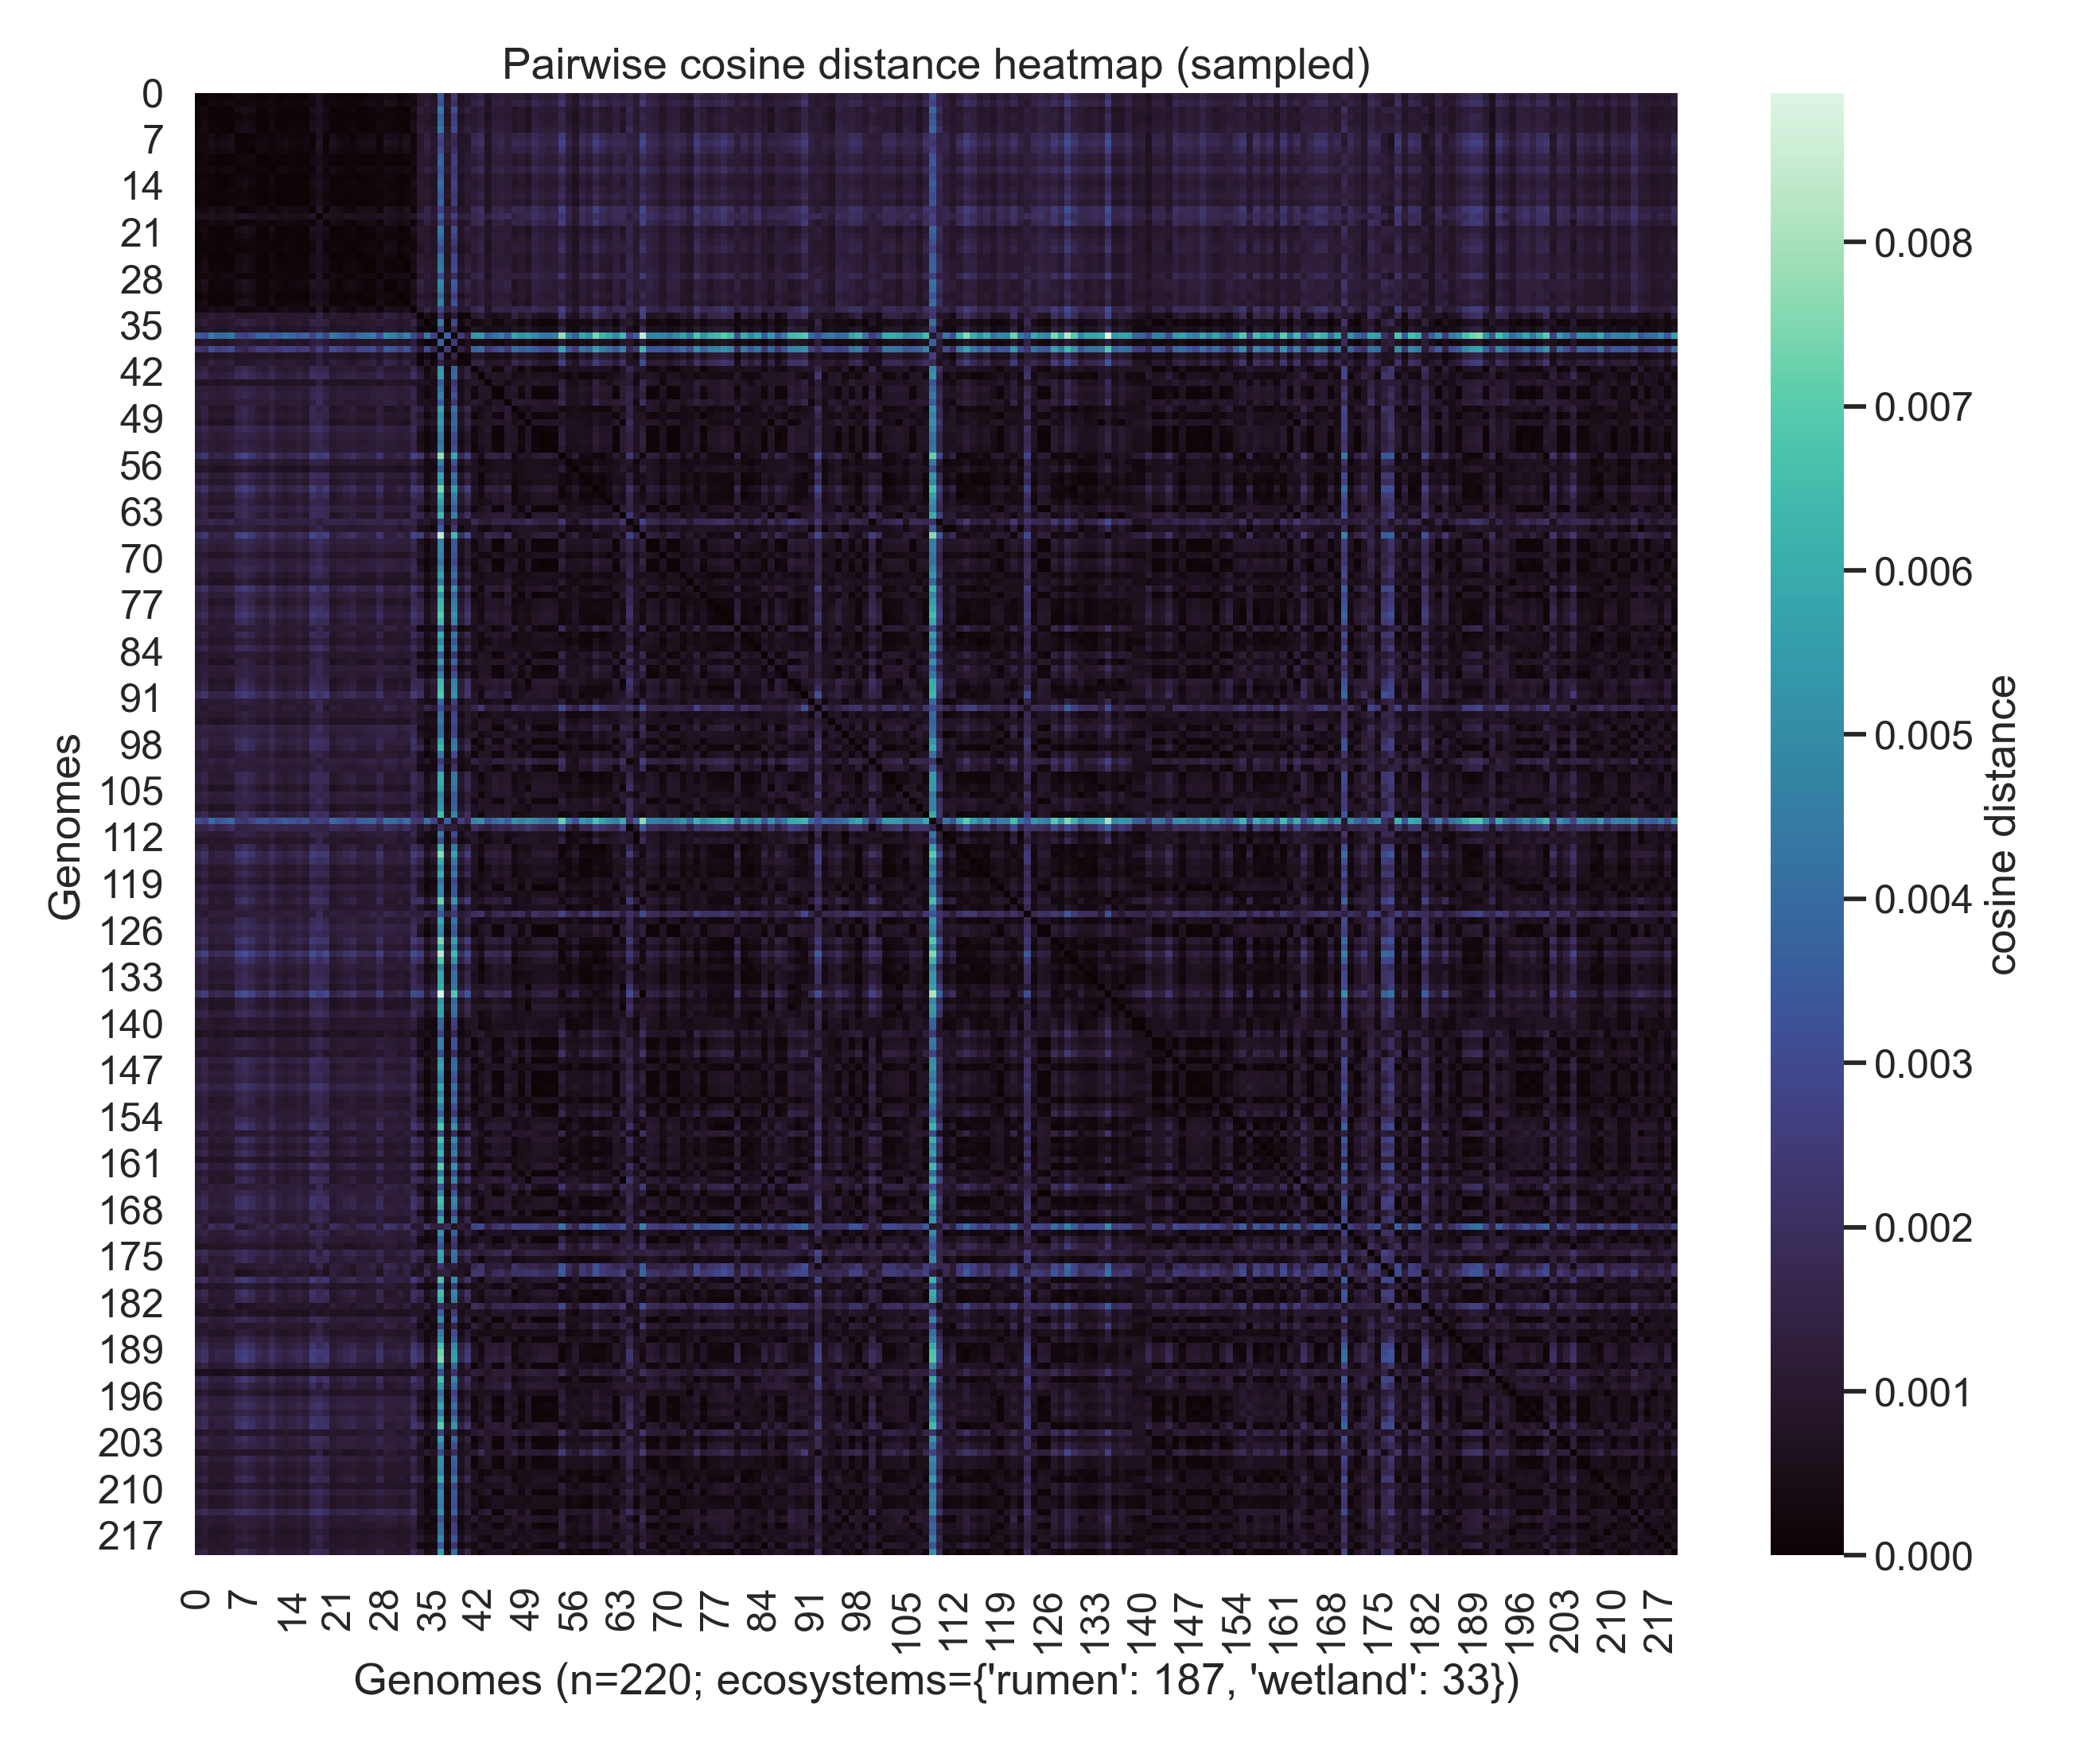

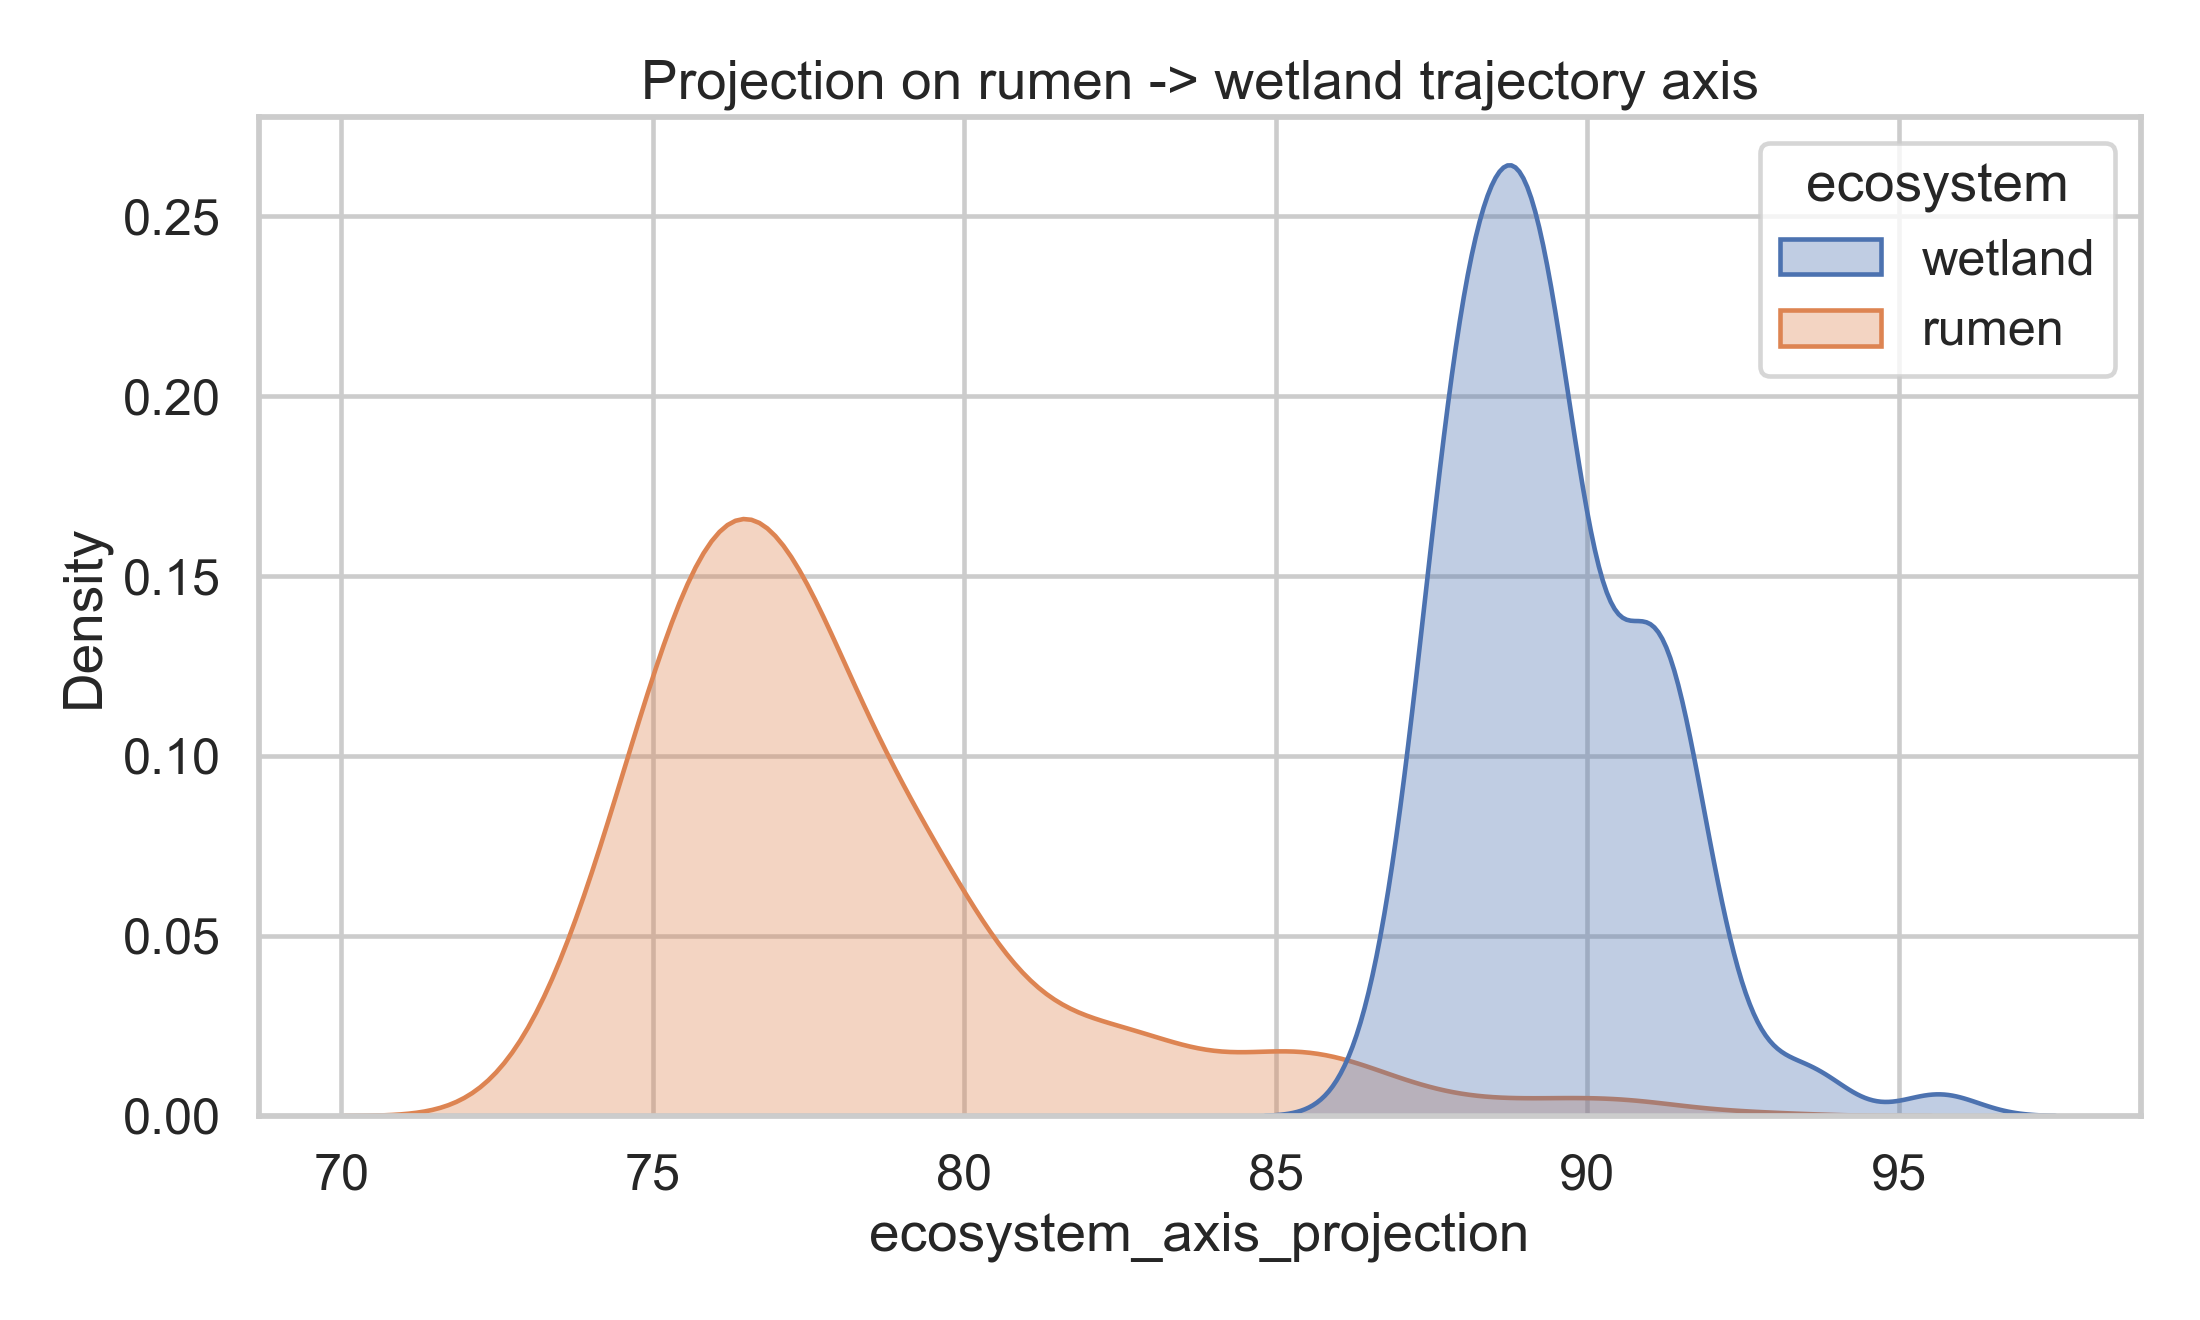

In [5]:
from IPython.display import Image, display

figs = sorted(paths["figures"].glob("*.png"))
print(f"Generated {len(figs)} static figure files")
for f in figs:
    print(" -", f.name)

for f in figs[:2]:
    display(Image(filename=str(f), width=900))